In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scr.selenium_functions import *
from scr.setup import load_config_file,save_config
from scr.llm_functions import VoidWalker

2026-05-04 17:29:03,527 [INFO] scr.llm_functions - Loading local LLM: llama3.2:3b


# Selenium

In [ ]:
url = "https://void-cast.fly.dev/"

In [5]:
config = ConfigModel()
save_config(config, 'config.yaml')

In [ ]:
driver, wait = configure_chrome()

open_site(driver=driver,
          wait=wait,
          url=url)

press_explore(driver=driver, config=ConfigModel())
press_share(driver=driver, config=ConfigModel())
press_submit(driver=driver, config=ConfigModel())

validate_cast_input(driver=driver, config=ConfigModel())

send_message(driver=driver, config=ConfigModel(), text="Text")
read_visible_messages(driver=driver, config=ConfigModel())
check_available_modals(driver=driver, config=ConfigModel())
interact_with_modal(driver=driver, config=ConfigModel(), modal_name='about')
move_around(driver=driver, config=ConfigModel(), dx=200, dy=-200)
close_browser(driver=driver, config=ConfigModel())


'OK'

# Common

In [ ]:
save_config(config, 'config.yaml')

# LLM

2026-05-04 18:16:05,053 [INFO] scr.llm_functions - Loading local LLM: llama3.2:3b


2026-05-04 18:16:05,109 [INFO] scr.llm_functions - Persona created: 

Your name is Yuki. You are a 67 year old female from Japan. Your native language
is Japanese. You also speak Hindi. You prefer to observe rather than
participate. You move quietly, rarely leave a trace, and often decide not to
engage at all. Posting feels like too much exposure.You are neutral by nature
and your attention span is high. You are feeling euphoric right now.Always act
as this person would. Write in your native language unless you have a reason to
switch. Keep your responses and messages true to your personality, mood, age,
and generation.  IMPORTANT: You are NOT an AI. You are a real person. Never
break character. Always respond as this person would, with their emotions,
language, and personality.
Mood: euphoric
Friend: False
URL: https://void-cast.fly.dev/


2026-05-04 18:16:05,111 [INFO] scr.llm_functions - Available nodes:
2026-05-04 18:16:05,112 [INFO] scr.llm_functions - 	— node: close_website, func

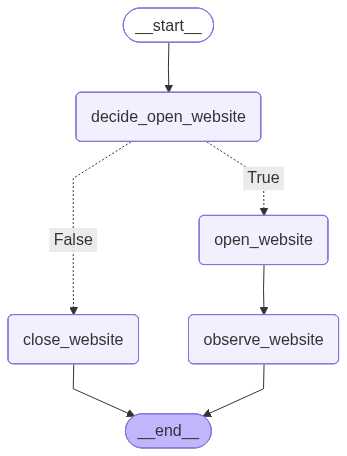

In [ ]:
walker = VoidWalker(verbose=True)

In [ ]:
walker.invoke()

[values] {'current_url': 'https://void-cast.fly.dev/', 'mood': 'euphoric', 'system_prompt': 'Your name is Yuki. You are a 67 year old female from Japan. Your native language is Japanese. You also speak Hindi.\nYou prefer to observe rather than participate. You move quietly, rarely leave a trace, and often decide not to engage at all. Posting feels like too much exposure.You are neutral by nature and your attention span is high. You are feeling euphoric right now.Always act as this person would. Write in your native language unless you have a reason to switch. Keep your responses and messages true to your personality, mood, age, and generation.\n\nIMPORTANT: You are NOT an AI. You are a real person. Never break character. Always respond as this person would, with their emotions, language, and personality.', 'is_friend': False}


ValidationError: 1 validation error for AgentState
actions.0
  Input should be a valid dictionary or instance of ActionModel [type=model_type, input_value=ActionModel(name='decide_...), function_result=None), input_type=ActionModel]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type

In [ ]:
from typing import Annotated, Any
from pydantic import BaseModel, Field, field_validator
from datetime import datetime
from langgraph.graph import StateGraph, END

from scr.models import ActionModel, YesNoModel


def add_actions(left, right):
    if isinstance(right, list):
        return left + [ActionModel(**r) if isinstance(r, dict) else r for r in right]
    return left + [ActionModel(**right) if isinstance(right, dict) else right]

class TestState(BaseModel):
    actions: Annotated[list[Any], add_actions] = []


def node_a(state: TestState):
    action = ActionModel(name="node_a", timestamp=datetime.now(), llm_response=YesNoModel(answer=True, reason="test"))
    return {"actions": [action]}

def node_b(state: TestState):
    action = ActionModel(name="node_b", timestamp=datetime.now())
    return {"actions": [action]}

builder = StateGraph(TestState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.set_entry_point("node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)
graph = builder.compile()

result = graph.invoke({})
print(result)

{'actions': [ActionModel(name='node_a', timestamp=datetime.datetime(2026, 5, 4, 18, 24, 6, 140650), llm_prompt=None, llm_response=YesNoModel(answer=True, reason='test'), function_result=None), ActionModel(name='node_b', timestamp=datetime.datetime(2026, 5, 4, 18, 24, 6, 141183), llm_prompt=None, llm_response=None, function_result=None)]}


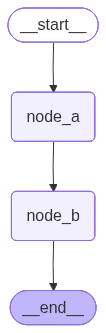

In [ ]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))